### Gamma Ray Bursts

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 

In [1]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing

In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

Let's start by looking at the variables T90 ('Duration of the time interval during which 90% of the GRB photon counts are observed'), fluence ('The time integrated total energy per unit surface') and redshift ('Distance to the GRB'):

Text(0.5, 1.0, 'Redshift Distribution')

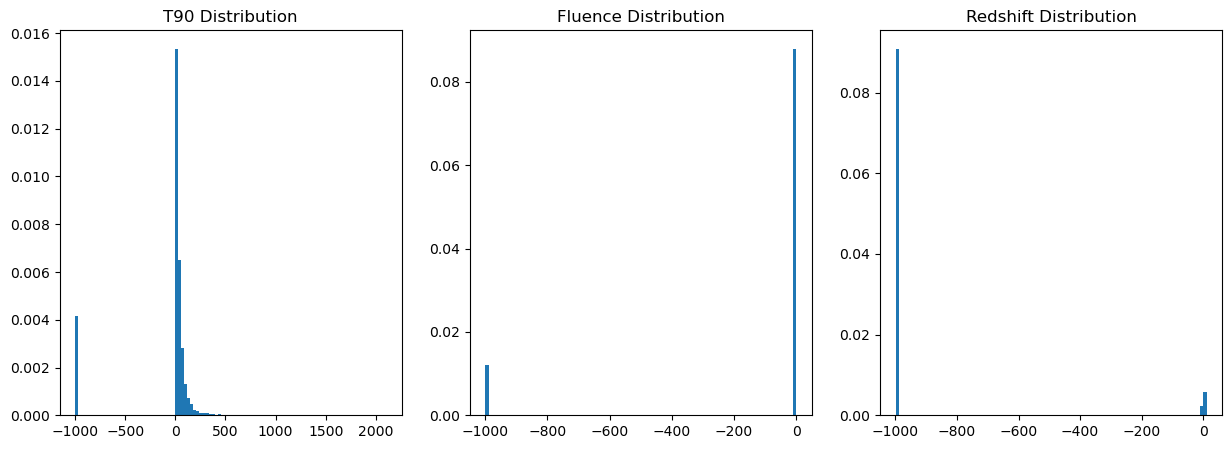

In [3]:
T90 = data[6].astype(float)
fluence = data[9].astype(float)
z = data[11].astype(float)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].hist(T90, bins=100, density=True)
ax[0].set_title("T90 Distribution")
ax[1].hist(fluence, bins=100, density=True)
ax[1].set_title("Fluence Distribution")
ax[2].hist(z, bins=100, density=True)
ax[2].set_title("Redshift Distribution")

There is clearly some missing data between -1000 and 0! Let's just consider the positive values and the log of the distributions:

Text(0.5, 1.0, 'Redshift Distribution')

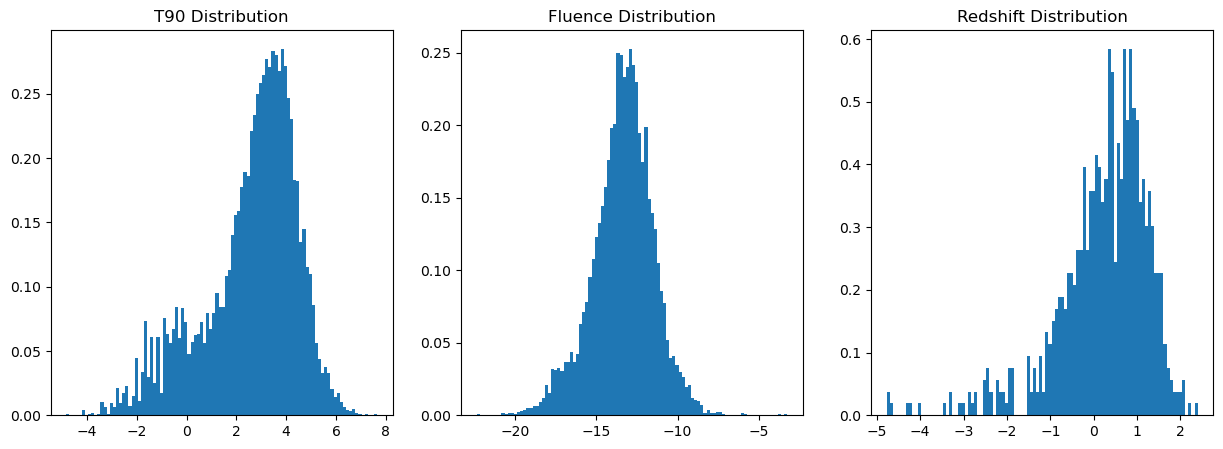

In [4]:
T90 = T90[T90>0]
fluence = fluence[fluence>0]
z = z[z>0]

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].hist(np.log(T90), bins=100, density=True)
ax[0].set_title("T90 Distribution")
ax[1].hist(np.log(fluence), bins=100, density=True)
ax[1].set_title("Fluence Distribution")
ax[2].hist(np.log(z), bins=100, density=True)
ax[2].set_title("Redshift Distribution")

It seems like there are two different modes, possibly corresponding to long and short GRB! Let's now focus on T90, where this bimodal distribution is more visible. First of all, let's try a KDE with different bandwidths:

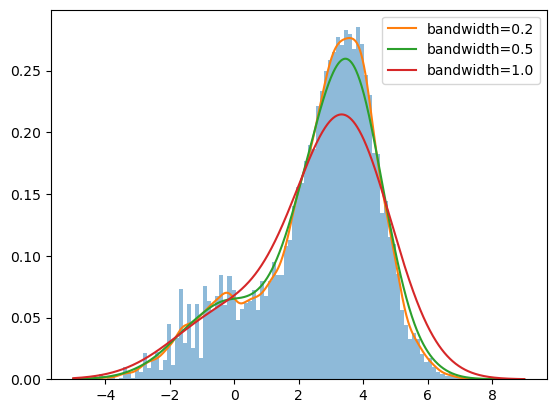

In [5]:
def kde(data, x_grid, bandwidth = 1.0):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, None])
    log_pdf = kde_skl.score_samples(x_grid[:, None])
    return np.exp(log_pdf)

x_grid =np.linspace(-5,9,1000)
kde_02 = kde(np.log(T90), x_grid, bandwidth=0.2)
kde_05 = kde(np.log(T90), x_grid, bandwidth=0.5)
kde_10 = kde(np.log(T90), x_grid, bandwidth=1.0)

plt.hist(np.log(T90), bins=100, density=True, alpha=0.5)
plt.plot(x_grid, kde_02, label='bandwidth=0.2')
plt.plot(x_grid, kde_05, label='bandwidth=0.5')
plt.plot(x_grid, kde_10, label='bandwidth=1.0')
plt.legend()

If the bandwidth is too large (1.0), it doesn't catch the bimodal distribution. We can find the best bandwith by using a maximum likelihood estimator with cross validation:

In [6]:
bw_range = np.linspace(0.01, 1.0, 30) 
K = 3
grid = GridSearchCV(KernelDensity(), {'bandwidth': bw_range}, cv= K)
grid.fit(np.log(T90)[:, None])
bw_opt = grid.best_params_['bandwidth']
print('Optimal bandwidth = ', bw_opt)

Optimal bandwidth =  0.2831034482758621


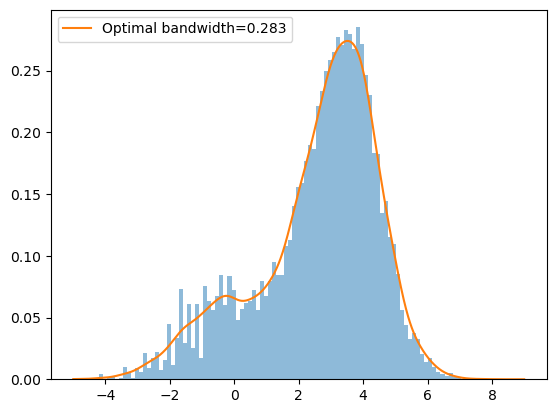

In [7]:
kde_opt = kde(np.log(T90), x_grid, bandwidth=bw_opt)
plt.hist(np.log(T90), bins=100, density=True, alpha=0.5)
plt.plot(x_grid, kde_opt, label=f'Optimal bandwidth={bw_opt:.3f}')
plt.legend()

Let's now try to do some clustering with K-Mean to separate the two populations:

In [8]:
clf = KMeans(n_clusters=2)
clf.fit(np.log(T90)[:, None])
centers = clf.cluster_centers_
labels = clf.predict(np.log(T90)[:, None]) 
x_labels = clf.predict(x_grid[:, None])

c:\Users\aless\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


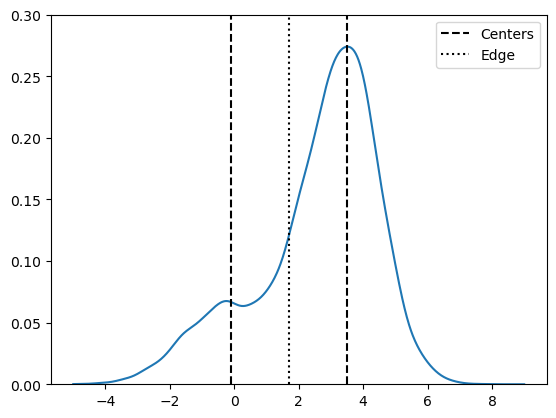

In [9]:
plt.plot(x_grid, kde_opt)
plt.vlines(centers[:,0], 0, 0.3, color = 'k', linestyle = '--', label = 'Centers')
plt.ylim(0, 0.3)

pop1 = np.log(T90)[labels==1]
edge = np.max(pop1)

plt.vlines(edge, 0, 0.3, color = 'k', linestyle = 'dotted', label = 'Edge')
plt.legend()

We have found the two centers and the separation edge of the two population through the variable T90! 

Let's try a different clustering method, Mean Shift, and compare the two results:

Text(0.5, 1.0, 'KMeans Clustering')

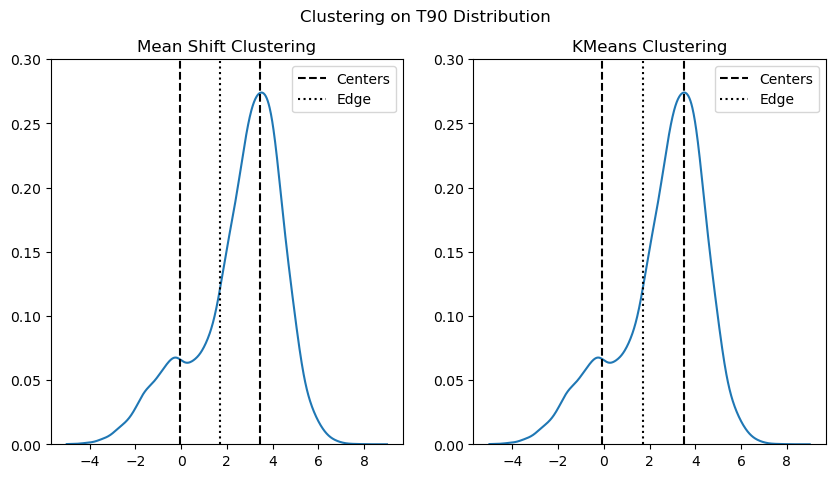

In [10]:
ms = MeanShift(bandwidth=2.4*bw_opt, bin_seeding=True)
ms.fit(np.log(T90)[:, None])

ms_centers = ms.cluster_centers_
ms_labels = ms.labels_
ms_pop1 = np.log(T90)[ms_labels==1]
ms_edge = np.max(ms_pop1)

fig, ax = plt.subplots(1, 2,figsize=(10,5))
fig.suptitle("Clustering on T90 Distribution")
ax[0].plot(x_grid, kde_opt)
ax[0].vlines(ms_centers[:,0], 0, 0.3, color = 'k', linestyle = '--', label = 'Centers')
ax[0].set_ylim(0, 0.3)
ax[0].vlines(ms_edge, 0, 0.3, color = 'k', linestyle = 'dotted', label = 'Edge')
ax[0].legend()
ax[0].set_title("Mean Shift Clustering")

ax[1].plot(x_grid, kde_opt)
ax[1].vlines(centers[:,0], 0, 0.3, color = 'k', linestyle = '--', label = 'Centers')
ax[1].set_ylim(0, 0.3)
ax[1].vlines(edge, 0, 0.3, color = 'k', linestyle = 'dotted', label = 'Edge')
ax[1].legend()
ax[1].set_title("KMeans Clustering")

In [11]:
print(f'MeanShift centers: {ms_centers[1,0], ms_centers[0,0]}')
print(f'Kmeans centers: {centers[1,0], centers[0,0]}')

MeanShift centers: (-0.049765110877938626, 3.4429098770586073)
Kmeans centers: (-0.09043228945528625, 3.4989387072711464)


They are almost the same!

Let's now do this for fluence and redshift and see if we can still find two pupolations:

In [12]:
K = 3

bw_range_flu = np.linspace(0.01, 1.5, 30) 
grid_flu = GridSearchCV(KernelDensity(), {'bandwidth': bw_range_flu}, cv= K)
grid_flu.fit(np.log(fluence)[:, None])
bw_opt_flu = grid_flu.best_params_['bandwidth']
print('Optimal bandwidth for fluence =', bw_opt_flu)

bw_range_z = np.linspace(0.01, 1.5, 30) 
grid_z = GridSearchCV(KernelDensity(), {'bandwidth': bw_range_z}, cv= K)
grid_z.fit(np.log(z)[:, None])
bw_opt_z = grid_z.best_params_['bandwidth']
print('Optimal bandwidth for redshift = ', bw_opt_z)

Optimal bandwidth for fluence = 0.9862068965517242
Optimal bandwidth for redshift =  0.21551724137931036


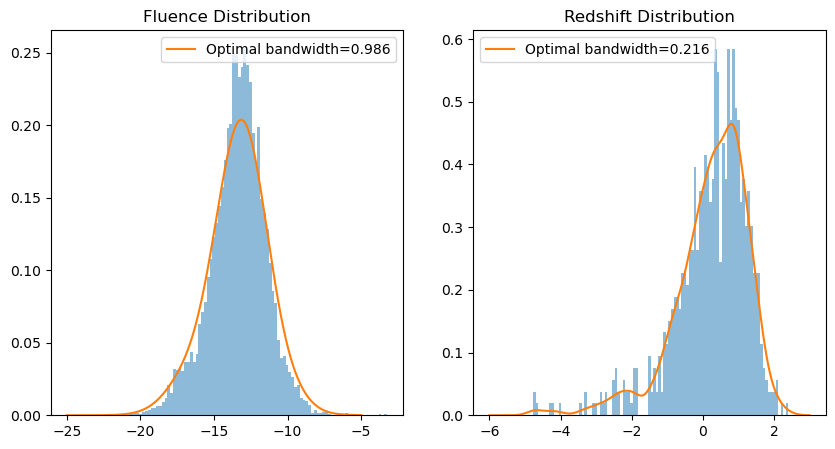

In [13]:
x_grid_flu = np.linspace(-25, -5, 1000)
x_grid_z = np.linspace(-6, 3, 1000)

kde_opt_flu = kde(np.log(fluence), x_grid_flu, bandwidth=bw_opt_flu)
kde_opt_z = kde(np.log(z), x_grid_z, bandwidth=bw_opt_z)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].hist(np.log(fluence), bins=100, density=True, alpha=0.5)
ax[0].plot(x_grid_flu, kde_opt_flu, label=f'Optimal bandwidth={bw_opt_flu:.3f}')
ax[0].set_title("Fluence Distribution")
ax[1].hist(np.log(z), bins=100, density=True, alpha=0.5)
ax[1].plot(x_grid_z, kde_opt_z, label=f'Optimal bandwidth={bw_opt_z:.3f}')
ax[1].set_title("Redshift Distribution")
ax[0].legend()
ax[1].legend()


From the fluence distribution it doesn't seem that there are two different modes, while in the redshift distribution we can observe somenthing. Let's check by doing clustering once again:

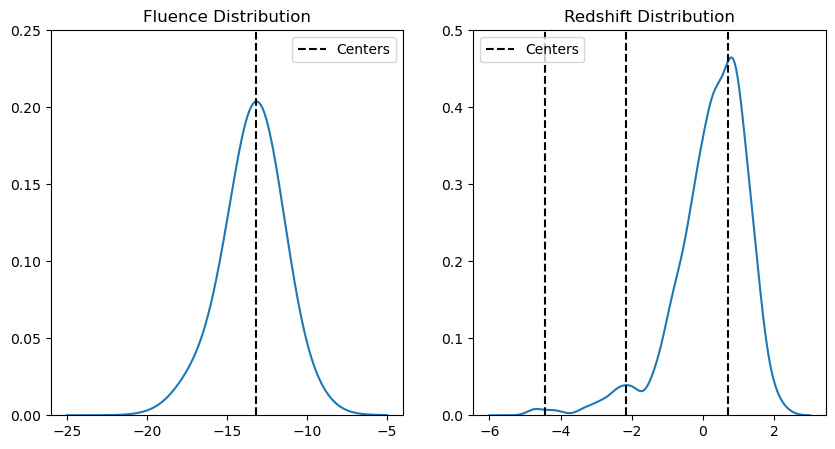

In [ ]:
clf = MeanShift(bandwidth=2.4*bw_opt_flu, bin_seeding=True)

clf_flu = clf.fit(np.log(fluence)[:, None])
centers_flu = clf_flu.cluster_centers_ 
labels_flu = clf_flu.labels_

clf = MeanShift(bandwidth=2.4*bw_opt_z, bin_seeding=True)
clf_z = clf.fit(np.log(z)[:, None])
centers_z = clf_z.cluster_centers_ 
labels_z = clf_z.labels_

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(x_grid_flu, kde_opt_flu)
ax[0].vlines(centers_flu[:,0], 0, 0.25, color = 'k', linestyle = '--', label = 'Centers')
ax[0].set_ylim(0, 0.25)
ax[0].set_title("Fluence Distribution")
ax[0].legend()

ax[1].plot(x_grid_z, kde_opt_z)
ax[1].vlines(centers_z[:,0], 0, 0.5, color = 'k', linestyle = '--', label = 'Centers')
ax[1].set_ylim(0, 0.5)
ax[1].set_title("Redshift Distribution")
ax[1].legend()

Again, in the fluence it seems to be just one mode, while in the redshift MeanShift finds three population. Still we can see that at low redshift data become very sparse, probably influencing this result.

So the variable through which we can better observe the presence of two different populations is T90!